# Notebook for testing

In [1]:
import pandas as pd
import plotly.express as px

In [2]:
def improve_col_display(df):
    '''This function replaces underscores in column names with spaces
    and also converts them to title space, thus improving their
    appearance within chart titles. 
    Since some values (e.g. 'ID') are best capitalized rather than
    converted to title case, the function also includes a 
    df.rename() col. This can be expanded as needed to address any
    issues caused by the title case conversion.
    '''
    df.columns = [column.replace('_', ' ').title() 
                  for column in df.columns]
    df.rename(
        columns = {'Student Id':'Student ID'}, inplace = True)

In [3]:
# Offline import option:
# df_curr_enrollment = pd.read_csv(
#     '../../Appendix/survey_results.csv')
# df_curr_enrollment

In [4]:
df_survey_results = pd.read_csv('https://raw.githubusercontent.com/\
kburchfiel/pfn/main/Appendix/survey_results.csv')
improve_col_display(df_survey_results)
df_survey_results

,Student ID,Starting Year,Season,Score
0,2020-1,2023,Fall,88
1,2020-2,2023,Fall,37
2,2020-3,2023,Fall,54
3,2020-4,2023,Fall,56
4,2020-5,2023,Fall,77
...,...,...,...,...
32763,2023-5439,2023,Spring,90
32764,2023-5440,2023,Spring,100
32765,2023-5441,2023,Spring,89
32766,2023-5442,2023,Spring,64


In [5]:
df_survey_results['Count'] = 1

df_curr_enrollment = (pd.read_csv(
    'https://raw.githubusercontent.com/kburchfiel/\
pfn/main/Appendix/curr_enrollment.csv'))

improve_col_display(df_curr_enrollment)

df_curr_enrollment['Count'] = 1
df_curr_enrollment.head()

,First Name,Last Name,Gender,Matriculation Year,Matriculation Number,Student ID,Date Of Birth,College,Class Of,Level,Level For Sorting,Count
0,Danielle,Wilson,F,2020,1,2020-1,2002-12-16,STC,2024,Fr,0,1
1,Anna,Smith,F,2020,2,2020-2,2002-09-26,STM,2024,Fr,0,1
2,Ann,Baker,F,2020,3,2020-3,2002-05-18,STC,2024,Fr,0,1
3,Jennifer,Costa,F,2020,4,2020-4,2002-11-15,STC,2024,Fr,0,1
4,Brenda,Wood,F,2020,5,2020-5,2002-06-21,STM,2024,Fr,0,1


In [6]:
df_survey_results_extra_data = df_survey_results.drop('Count', axis = 1).merge(
    df_curr_enrollment, on = 'Student ID', how = 'left')[
['Starting Year', 'Season', 'Score', 'Gender', 'Matriculation Year',
 'College', 'Class Of', 'Level', 'Level For Sorting', 'Count']]
df_survey_results_extra_data


,Starting Year,Season,Score,Gender,Matriculation Year,College,Class Of,Level,Level For Sorting,Count
0,2023,Fall,88,F,2020,STC,2024,Fr,0,1
1,2023,Fall,37,F,2020,STM,2024,Fr,0,1
2,2023,Fall,54,F,2020,STC,2024,Fr,0,1
3,2023,Fall,56,F,2020,STC,2024,Fr,0,1
4,2023,Fall,77,F,2020,STM,2024,Fr,0,1
...,...,...,...,...,...,...,...,...,...,...
32763,2023,Spring,90,M,2023,STL,2027,Se,3,1
32764,2023,Spring,100,M,2023,STM,2027,Se,3,1
32765,2023,Spring,89,M,2023,STL,2027,Se,3,1
32766,2023,Spring,64,M,2023,STB,2027,Se,3,1


In [7]:
df_curr_enrollment['Level'].value_counts()

Level
Se    5443
Ju    3999
So    3653
Fr    3289
Name: count, dtype: int64

I ended up not needing the following function, as dash-pivottable also accepts a list of dictionaries--and DataFrames can easily be converted into this format via `df_curr_enrollment.to_dict(orient = 'records')`.

In [8]:
def df_to_lol(df):
    '''Converts a DataFrame (passed to df) to a list of lists (or 'lol') 
    that can be used as the data argument when initializing 
    a dash_pivottable.PivotTable().'''
    dict_df = (
    df.copy().to_dict(orient='split'))
    lol = dict_df['data'].copy()
    lol.insert(
        0, dict_df['columns'])
    return lol
    

In [9]:
df_simple_enrollment_pivot = df_curr_enrollment.pivot_table(
    index = ['College', 'Level For Sorting', 'Level'],
    values = 'Count', aggfunc = 'sum').reset_index()
df_simple_enrollment_pivot.head()


,College,Level For Sorting,Level,Count
0,STB,0,Fr,797
1,STB,1,So,975
2,STB,2,Ju,1084
3,STB,3,Se,1309
4,STC,0,Fr,997


In [10]:
df_enrollment_by_college = df_curr_enrollment.pivot_table(
    index = ['College'],
    values = 'Count', aggfunc = 'sum').reset_index()
df_enrollment_by_college

,College,Count
0,STB,4165
1,STC,3670
2,STL,3729
3,STM,4820


In [23]:
df_enrollment_by_level = df_curr_enrollment.pivot_table(
    index = ['Level For Sorting', 'Level'],
    values = 'Count', aggfunc = 'sum').reset_index()
df_enrollment_by_level

,Level For Sorting,Level,Count
0,0,Fr,3289
1,1,So,3653
2,2,Ju,3999
3,3,Se,5443


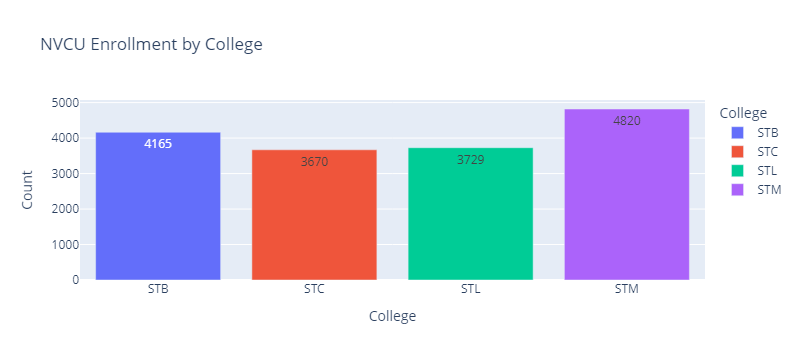

In [25]:
fig_enrollment_by_college = px.bar(df_enrollment_by_college, 
       x = 'College', y = 'Count', color = 'College',
      text_auto = '.0f',
      title = 'NVCU Enrollment by College')
fig_enrollment_by_college

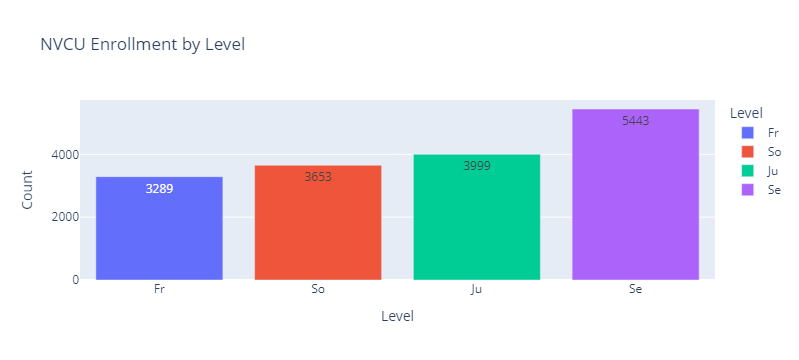

In [24]:
fig_enrollment_by_level = px.bar(df_enrollment_by_level, 
       x = 'Level', y = 'Count', color = 'Level',
      text_auto = '.0f',
      title = 'NVCU Enrollment by Level')
fig_enrollment_by_level

In [12]:
df_curr_enrollment['College'].unique()

array(['STC', 'STM', 'STL', 'STB'], dtype=object)

In [13]:
df_curr_enrollment['All Students'] = 'All Students'
df_total_enrollment = df_curr_enrollment.pivot_table(
    index = ['All Students'],
    values = 'Count', aggfunc = 'sum').reset_index()
df_total_enrollment

,All Students,Count
0,All Students,16384


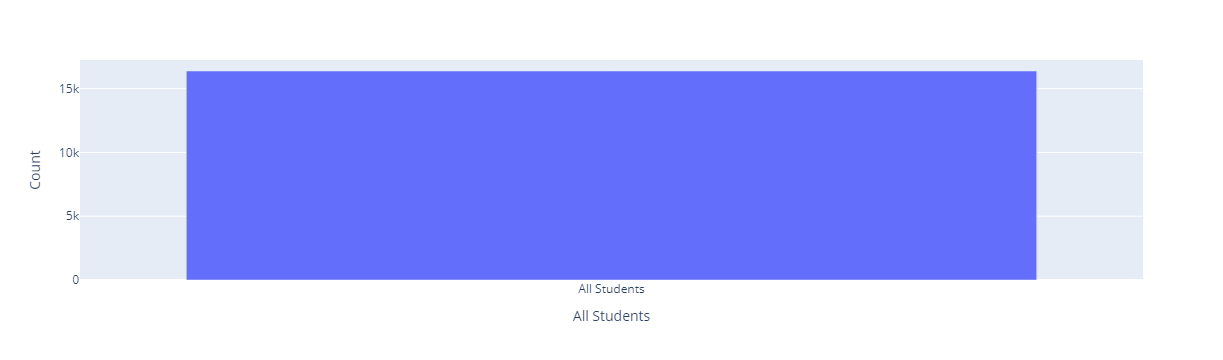

In [14]:
px.bar(df_total_enrollment,
       x = 'All Students', y = 'Count')

In [15]:
df_simple_enrollment_pivot = df_curr_enrollment.pivot_table(
    index = ['College', 'Level For Sorting', 'Level'],
    values = 'Count', aggfunc = 'sum').reset_index()
df_simple_enrollment_pivot['College/Level'] = (
    df_simple_enrollment_pivot['College'] 
    + '/' + df_simple_enrollment_pivot['Level'])
df_simple_enrollment_pivot.head()


,College,Level For Sorting,Level,Count,College/Level
0,STB,0,Fr,797,STB/Fr
1,STB,1,So,975,STB/So
2,STB,2,Ju,1084,STB/Ju
3,STB,3,Se,1309,STB/Se
4,STC,0,Fr,997,STC/Fr


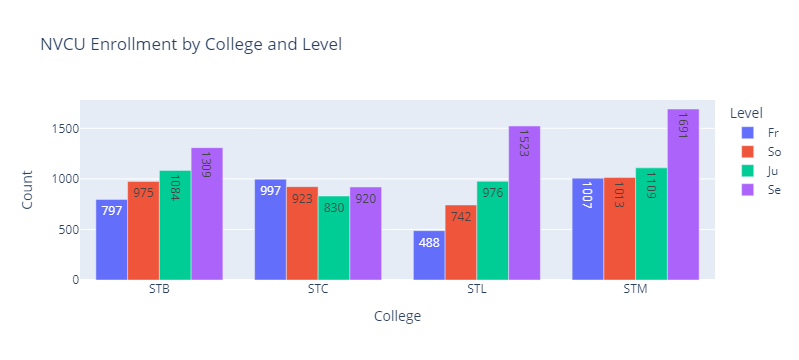

In [16]:
fig_simple_enrollment = px.bar(df_simple_enrollment_pivot, 
       x = 'College', y = 'Count', color = 'Level',
      barmode = 'group',
      text_auto = '.0f',
      title = 'NVCU Enrollment by College and Level')
fig_simple_enrollment

## Additional chart(s) for fixed dashboard:

In [20]:
df_enrollment_by_college_and_level = df_curr_enrollment.pivot_table(
    index = ['College', 'Level For Sorting', 'Level'],
    values = 'Count', aggfunc = 'sum').reset_index()
df_enrollment_by_college_and_level.head()

,College,Level For Sorting,Level,Count
0,STB,0,Fr,797
1,STB,1,So,975
2,STB,2,Ju,1084
3,STB,3,Se,1309
4,STC,0,Fr,997


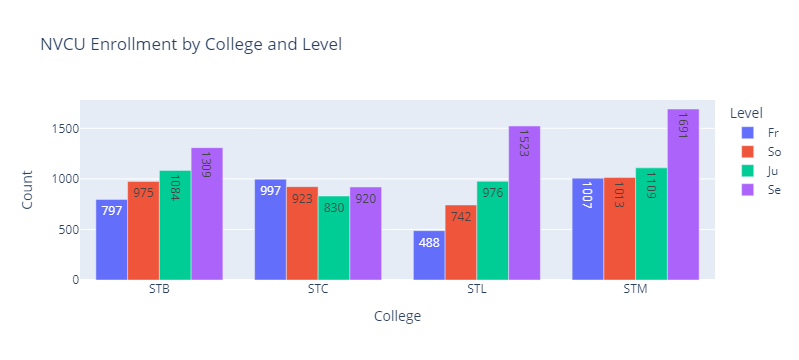

In [21]:
fig_enrollment_by_college_and_level = px.bar(df_enrollment_by_college_and_level, 
       x = 'College', y = 'Count', color = 'Level',
      barmode = 'group',
      text_auto = '.0f',
      title = 'NVCU Enrollment by College and Level')
fig_enrollment_by_college_and_level